<a href="https://colab.research.google.com/github/alirezakiann/snappfood-sentiment/blob/main/notebooks/03_baseline_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 - Baseline Models (TF-IDF + Scikit-Learn)
Turn text into numbers with **TF-IDF**, then compare three classic classifiers and three ways of splitting text into features.

Questions this notebook answers:
1. Which model works best: Naive Bayes, Logistic Regression or Linear SVM?
2. Do word pairs (bigrams) help, as notebooks 01 and 02 suggested?
3. Do character n-grams help with Persian spelling variations?
4. What has the model actually learned?

## 0. Setup

In [1]:
!pip install -q hazm

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.2/887.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 15.2 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount("/content/drive")

import os
BASE_DIR = "/content/drive/MyDrive/snappfood-sentiment"
PROC_DIR = f"{BASE_DIR}/processed"
MODEL_DIR = f"{BASE_DIR}/models"
os.makedirs(MODEL_DIR, exist_ok=True)

for name in ["train", "val", "test"]:
    print(name, "found:", os.path.exists(f"{PROC_DIR}/{name}.csv"))

Mounted at /content/drive
train found: True
val found: True
test found: True


In [3]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             classification_report, ConfusionMatrixDisplay)

pd.set_option("display.max_colwidth", 150)
sns.set_theme(style="whitegrid")

## 1. Load the split from notebook 02

In [4]:
train = pd.read_csv(f"{PROC_DIR}/train.csv")
val = pd.read_csv(f"{PROC_DIR}/val.csv")
test = pd.read_csv(f"{PROC_DIR}/test.csv")

for d in (train, val, test):
    d["clean_text"] = d["clean_text"].fillna("")

X_train, y_train = train["clean_text"], train["sentiment"]
X_val, y_val = val["clean_text"], val["sentiment"]
X_test, y_test = test["clean_text"], test["sentiment"]

print(f"train {len(train):,} | val {len(val):,} | test {len(test):,}")
train.head()

train 55,280 | val 6,910 | test 6,910


,comment,clean_text,label,sentiment
0,راضیم ازتون مثل همیشه …سربلند باشید,راضیم ازتون همیشه سربلند باشید,HAPPY,1
1,صابونی که فرستاده بودند پنپش شکسته و غیر قابل استفاده بود,صابونی فرستاده پنپش شکسته غیر قابل‌استفاده,SAD,0
2,پرتغال پوسیده بود. انار سفید و کاملا ترش. گلابی خیلی بد. به جای سیب سبز، سیب زرد ارسال شد! فلفل سبز بی کیفیت.,پرتغال پوسیده انار سفید کاملا ترش گلابی خیلی بد سیب سبز سیب زرد ارسال فلفل سبز بی‌کیفیت,SAD,0
3,مثل همیشه تازه و خوشمزه ممنون,همیشه تازه خوشمزه ممنون,HAPPY,1
4,سفارش ما بعد از ۲ ساعت رسید دستمان,سفارش ساعت رسید دستمان,SAD,0


## 2. The floor: a model that always guesses the same class
Any real model must beat this. With balanced classes it should be about 50%.

In [5]:
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
print(f"Dummy accuracy on validation: {accuracy_score(y_val, dummy.predict(X_val)):.3f}")

Dummy accuracy on validation: 0.503


## 3. What TF-IDF does
Each review becomes a long vector with one number per word in the vocabulary.
- **TF** (term frequency): how often the word appears in *this* review
- **IDF** (inverse document frequency): words that appear in *every* review (like «غذا») get a lower weight, rare but meaningful words get a higher one

A tiny example:

In [6]:
demo_texts = ["غذا عالی", "غذا سرد", "غذا خوب نبود"]
demo_vec = TfidfVectorizer(ngram_range=(1, 2))
demo_matrix = demo_vec.fit_transform(demo_texts)

pd.DataFrame(demo_matrix.toarray().round(2), columns=demo_vec.get_feature_names_out(), index=demo_texts)

,خوب,خوب نبود,سرد,عالی,غذا,غذا خوب,غذا سرد,غذا عالی,نبود
غذا عالی,0.00,0.00,0.00,0.65,0.39,0.00,0.00,0.65,0.00
غذا سرد,0.00,0.00,0.65,0.00,0.39,0.00,0.65,0.00,0.00
غذا خوب نبود,0.48,0.48,0.00,0.00,0.28,0.48,0.00,0.00,0.48


«غذا» is in all three reviews, so it gets the lowest weight in each row. With `ngram_range=(1, 2)` the pair «خوب نبود» becomes its own feature.

## 4. Experiment: 3 feature types x 3 models
Feature types:
- **word 1-gram**: single words only
- **word 1-2 gram**: single words + word pairs (catches «خوب نبود»)
- **char 2-5 gram**: pieces of 2 to 5 letters inside words. Robust to spelling variations like «مرغها» vs «مرغ‌ها»

All models are trained on **train** and compared on **validation**. The test set stays untouched.

In [7]:
FEATURES = {
    "word 1-gram":   dict(analyzer="word", ngram_range=(1, 1), min_df=2, sublinear_tf=True),
    "word 1-2 gram": dict(analyzer="word", ngram_range=(1, 2), min_df=2, sublinear_tf=True),
    "char 2-5 gram": dict(analyzer="char_wb", ngram_range=(2, 5), min_df=3, sublinear_tf=True, max_features=300_000),
}

MODELS = {
    "Naive Bayes":         lambda: MultinomialNB(),
    "Logistic Regression": lambda: LogisticRegression(max_iter=2000),
    "Linear SVM":          lambda: LinearSVC(),
}

def scores(y_true, y_pred):
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "f1":        f1_score(y_true, y_pred, average="macro"),
        "precision": precision_score(y_true, y_pred),
        "recall":    recall_score(y_true, y_pred),
    }

results = []
for feat_name, feat_params in FEATURES.items():
    vec = TfidfVectorizer(**feat_params)
    Xtr = vec.fit_transform(X_train)
    Xva = vec.transform(X_val)
    print(f"{feat_name:14} -> {Xtr.shape[1]:,} features")

    for model_name, make_model in MODELS.items():
        start = time.time()
        model = make_model().fit(Xtr, y_train)
        seconds = time.time() - start
        results.append({"features": feat_name, "model": model_name,
                        **scores(y_val, model.predict(Xva)), "train_sec": round(seconds, 1)})

results = pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)
results.round(4)

word 1-gram    -> 11,259 features
word 1-2 gram  -> 73,415 features
char 2-5 gram  -> 50,119 features


,features,model,accuracy,f1,precision,recall,train_sec
0,word 1-2 gram,Logistic Regression,0.8679,0.8676,0.8953,0.8314,0.7
1,char 2-5 gram,Logistic Regression,0.8631,0.8629,0.8885,0.8285,2.3
2,word 1-gram,Logistic Regression,0.8628,0.8626,0.8853,0.8317,1.3
3,word 1-2 gram,Naive Bayes,0.8585,0.8579,0.9053,0.7988,0.0
4,char 2-5 gram,Linear SVM,0.8541,0.8540,0.8725,0.8273,5.4
5,word 1-2 gram,Linear SVM,0.8535,0.8534,0.8685,0.8311,0.4
6,word 1-gram,Linear SVM,0.8502,0.8501,0.8658,0.8267,0.4
7,word 1-gram,Naive Bayes,0.8424,0.8418,0.8846,0.7854,0.0
8,char 2-5 gram,Naive Bayes,0.8356,0.8347,0.8856,0.7685,0.1


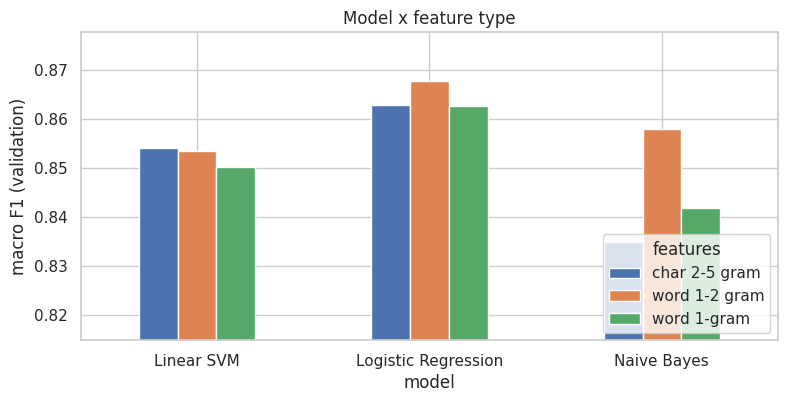

features,char 2-5 gram,word 1-2 gram,word 1-gram
model,,,
Linear SVM,0.8540,0.8534,0.8501
Logistic Regression,0.8629,0.8676,0.8626
Naive Bayes,0.8347,0.8579,0.8418


In [8]:
pivot = results.pivot(index="model", columns="features", values="f1")
ax = pivot.plot(kind="bar", figsize=(9, 4), rot=0)
ax.set_ylim(pivot.values.min() - 0.02, pivot.values.max() + 0.01)
ax.set_ylabel("macro F1 (validation)")
ax.set_title("Model x feature type")
plt.legend(title="features", loc="lower right")
plt.show()

pivot.round(4)

## 5. Tuning the regularization strength
`C` (for LR and SVM) and `alpha` (for Naive Bayes) control **regularization**: how much the model is stopped from memorizing the training data.
- small `C` / large `alpha` -> simpler model, may underfit
- large `C` / small `alpha` -> more complex model, may overfit

We tune each model on the best feature type from the experiment above.

In [9]:
best_feat = results.iloc[0]["features"]
print("Best feature type:", best_feat)

vec = TfidfVectorizer(**FEATURES[best_feat])
Xtr = vec.fit_transform(X_train)
Xva = vec.transform(X_val)

GRID = {
    "Naive Bayes":         ("alpha", [0.03, 0.1, 0.3, 1.0], lambda v: MultinomialNB(alpha=v)),
    "Logistic Regression": ("C", [0.3, 1, 3, 10, 30], lambda v: LogisticRegression(C=v, max_iter=3000)),
    "Linear SVM":          ("C", [0.03, 0.1, 0.3, 1, 3], lambda v: LinearSVC(C=v)),
}

tuning = []
for model_name, (param, values, make) in GRID.items():
    for v in values:
        m = make(v).fit(Xtr, y_train)
        tuning.append({"model": model_name, "param": param, "value": v,
                       "train_f1": f1_score(y_train, m.predict(Xtr), average="macro"),
                       "val_f1": f1_score(y_val, m.predict(Xva), average="macro")})

tuning = pd.DataFrame(tuning)
tuning.round(4)

Best feature type: word 1-2 gram


,model,param,value,train_f1,val_f1
0,Naive Bayes,alpha,0.03,0.9257,0.8449
1,Naive Bayes,alpha,0.10,0.9182,0.8505
2,Naive Bayes,alpha,0.30,0.9084,0.8526
3,Naive Bayes,alpha,1.00,0.8921,0.8579
4,Logistic Regression,C,0.30,0.8774,0.8665
5,Logistic Regression,C,1.00,0.8967,0.8676
6,Logistic Regression,C,3.00,0.9269,0.8673
7,Logistic Regression,C,10.00,0.9627,0.8576
8,Logistic Regression,C,30.00,0.9752,0.8458
9,Linear SVM,C,0.03,0.8764,0.8658


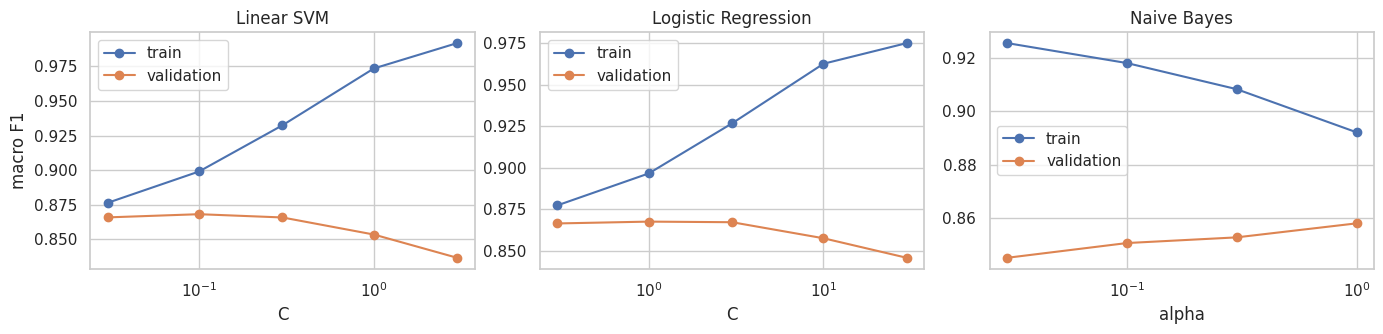

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, (model_name, part) in zip(axes, tuning.groupby("model")):
    ax.plot(part["value"], part["train_f1"], "o-", label="train")
    ax.plot(part["value"], part["val_f1"], "o-", label="validation")
    ax.set_xscale("log")
    ax.set_title(model_name)
    ax.set_xlabel(part["param"].iloc[0])
    ax.legend()
axes[0].set_ylabel("macro F1")
plt.tight_layout()
plt.show()

The gap between the train and validation lines shows **overfitting**. The best setting is where the validation line peaks.

In [11]:
best = tuning.sort_values("val_f1", ascending=False).iloc[0]
print(f"Best: {best['model']} with {best['param']}={best['value']}  (val F1 = {best['val_f1']:.4f})")

best_model_name, best_param, best_value = best["model"], best["param"], best["value"]
make_best = GRID[best_model_name][2]

def build_final_pipeline():
    return Pipeline([
        ("tfidf", TfidfVectorizer(**FEATURES[best_feat])),
        ("clf", make_best(best_value)),
    ])

Best: Linear SVM with C=0.1  (val F1 = 0.8682)


## 6. Is the result stable? 5-fold cross-validation
One validation split could be lucky. Cross-validation trains and tests 5 times on different parts of the training data.

In [12]:
%%time
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(build_final_pipeline(), X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)

print("F1 per fold:", cv_scores.round(4))
print(f"mean = {cv_scores.mean():.4f}  |  std = {cv_scores.std():.4f}")

F1 per fold: [0.8626 0.8588 0.8615 0.8615 0.8576]
mean = 0.8604  |  std = 0.0019
CPU times: user 162 ms, sys: 52.9 ms, total: 215 ms
Wall time: 9.39 s


## 7. Final test
Now, and only now, we touch the test set. The final model is trained on **train + validation**, then evaluated once on test.

In [13]:
final_model = build_final_pipeline()
final_model.fit(pd.concat([X_train, X_val]), pd.concat([y_train, y_val]))

test_pred = final_model.predict(X_test)
print(f"Final model: {best_feat} + {best_model_name} ({best_param}={best_value})\n")
print(classification_report(y_test, test_pred, target_names=["SAD", "HAPPY"], digits=4))

Final model: word 1-2 gram + Linear SVM (C=0.1)

              precision    recall  f1-score   support

         SAD     0.8289    0.9198    0.8720      3477
       HAPPY     0.9086    0.8077    0.8552      3433

    accuracy                         0.8641      6910
   macro avg     0.8688    0.8638    0.8636      6910
weighted avg     0.8685    0.8641    0.8636      6910



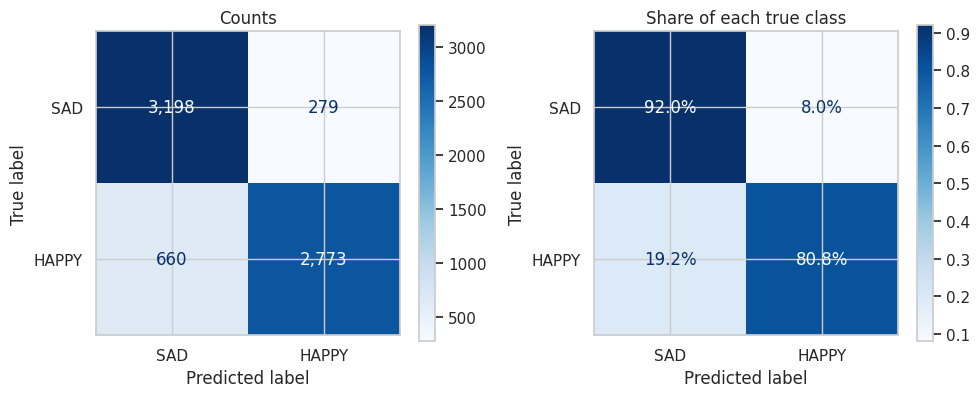

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, display_labels=["SAD", "HAPPY"],
                                        cmap="Blues", values_format=",", ax=axes[0])
axes[0].set_title("Counts")
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, display_labels=["SAD", "HAPPY"],
                                        cmap="Blues", normalize="true", values_format=".1%", ax=axes[1])
axes[1].set_title("Share of each true class")
plt.tight_layout()
plt.show()

## 8. What did the model learn?
Logistic Regression gives every feature a weight: positive weights push toward HAPPY, negative toward SAD.
We use word 1-2 grams here because they are readable (character pieces are not).

In [15]:
explain = Pipeline([
    ("tfidf", TfidfVectorizer(**FEATURES["word 1-2 gram"])),
    ("clf", LogisticRegression(C=3, max_iter=3000)),
]).fit(X_train, y_train)

names = explain.named_steps["tfidf"].get_feature_names_out()
coefs = explain.named_steps["clf"].coef_[0]
order = np.argsort(coefs)

pd.DataFrame({
    "most SAD": names[order[:25]], "weight (SAD)": coefs[order[:25]].round(2),
    "most HAPPY": names[order[::-1][:25]], "weight (HAPPY)": coefs[order[::-1][:25]].round(2),
})

,most SAD,weight (SAD),most HAPPY,weight (HAPPY)
0,افتضاح,-7.56,عالی,18.52
1,اصلا,-7.21,خوشمزه,12.45
2,خوشمزه نبود,-7.13,خوب,12.30
3,بدترین,-7.10,ممنون,9.54
4,پایین,-7.09,عالیه,8.74
5,متاسفم,-6.47,ممنونم,7.51
6,بد,-6.44,سریع,7.41
7,خوب نبود,-6.13,بد نبود,7.38
8,ساعت,-5.74,بهترین,7.30
9,بی کیفیت,-5.19,راضیم,5.65


In [16]:
# how does the model treat «خوب» on its own vs. in pairs?
vocab = dict(zip(names, coefs))
for term in ["خوب", "خوب نبود", "خوب ولی", "بد", "بد نبود", "عالی", "سرد", "دیر", "دیر رسید"]:
    w = vocab.get(term)
    print(f"{term:12} {w:+.2f}" if w is not None else f"{term:12} (not in vocabulary)")

خوب          +12.30
خوب نبود     -6.13
خوب ولی      +0.47
بد           -6.44
بد نبود      +7.38
عالی         +18.52
سرد          -4.13
دیر          +0.26
دیر رسید     -0.61


## 9. A first look at the mistakes
A full error analysis comes in notebook 05. For now, the reviews the final model got most confidently wrong:

In [17]:
clf = final_model.named_steps["clf"]
if hasattr(clf, "decision_function"):
    score = final_model.decision_function(X_test)
else:
    score = final_model.predict_proba(X_test)[:, 1] - 0.5

errors = test.assign(pred=test_pred, score=score)
errors = errors[errors["pred"] != errors["sentiment"]].copy()
errors["confidence"] = errors["score"].abs()
print(f"Wrong predictions: {len(errors):,} of {len(test):,}")

errors.sort_values("confidence", ascending=False)[["comment", "label", "confidence"]].head(15)

Wrong predictions: 939 of 6,910


,comment,label,confidence
1841,خوشمزه بود و خیلى سریع رسید تشکر,SAD,2.326100
5238,خیلى خوشمزه بود. مرسى وان!,SAD,1.890517
3942,خیلی تازه و خوب بود و واقعا سریع,SAD,1.751155
2712,البته خیلی سریع سفارشمون رسید ممنون,SAD,1.720479
3438,بسیار خوب مزه دار شده بود و طعم خیلی خوبی داشت. سبزیجات تازه بودند و بسیار هم سریع رسید.,SAD,1.607330
2243,کلا خوب بود. ممنون,SAD,1.518980
1483,طعم متفاوت کیفیت عالی مواد تازه,SAD,1.504942
5235,اصلا پیتزا طعم خوبی نداشت یعنی کلا هیچ طعمی نداشت مزه خمیر و پنیر میداد و من از رستوران شما اصلا انتظار نداشتم,HAPPY,1.442604
2303,هر دو سرد بود,HAPPY,1.351389
2482,کروسان‌مثل همیشه تازه و عالی. ردولوت هم تازه خوب بود. ولی اگر به جای خامه از پنیر استفاده بشه بهتره. به موقع هم ارسال شد. سپاس از نان سحر و اسنپ فود,SAD,1.312412


## 10. Save the model

In [18]:
model_path = f"{MODEL_DIR}/baseline_tfidf_model.joblib"
joblib.dump(final_model, model_path)
print("Saved to:", model_path)

Saved to: /content/drive/MyDrive/snappfood-sentiment/models/baseline_tfidf_model.joblib


## 11. Try it on your own sentences
Same cleaning function as notebook 02, so new text is processed exactly like the training data.

In [19]:
import re
from hazm import Normalizer, stopwords_list

KEEP = {
    "نه", "نبود", "نیست", "نیستند", "ندارد", "ندارند", "نباید", "نمی‌شود", "هیچ", "بدون", "عدم", "غیر", "بی",
    "اما", "ولی", "بلکه", "حتی", "فقط", "تنها",
    "خیلی", "بسیار", "بسیاری", "کاملا", "کامل", "زیاد", "زیادی", "کم", "کمی", "بیش", "بیشتر", "پر", "کافی",
    "عالی", "خوب", "خوبی", "بهتر", "بهترین", "مناسب", "متاسفانه", "جدی",
    "رسید", "رسیدن", "دیر", "هنوز", "همیشه", "همواره", "دوباره",
}
STOPWORDS = set(stopwords_list()) - KEEP
normalizer = Normalizer()

URL_RE = re.compile(r"https?://\S+|www\.\S+")
REPEAT_RE = re.compile(r"(.)\1{2,}")
EMOJI_RE = re.compile("[\U0001F300-\U0001FAFF\U00002600-\U000027BF]")
PERSIAN = "\u0621-\u063A\u0641-\u064A\u067E\u0686\u0698\u06A9\u06AF\u06CC\u200c"
EMOJI_CHARS = "\U0001F300-\U0001FAFF\U00002600-\U000027BF"
NOT_ALLOWED_RE = re.compile(f"[^{PERSIAN}{EMOJI_CHARS}a-z\\s]")

def clean_text(text):
    text = str(text).lower()
    text = URL_RE.sub(" ", text)
    text = normalizer.normalize(text)
    text = REPEAT_RE.sub(r"\1", text)
    text = EMOJI_RE.sub(lambda m: f" {m.group(0)} ", text)
    text = NOT_ALLOWED_RE.sub(" ", text)
    tokens = [t.strip("\u200c") for t in text.split()]
    tokens = [t for t in tokens if t and t not in STOPWORDS and (len(t) > 1 or EMOJI_RE.match(t))]
    return " ".join(tokens)

In [20]:
my_reviews = [
    "غذا خیلی خوشمزه و داغ بود، ممنون",
    "اصلا خوب نبود، سرد رسید",
    "کیفیت خوب بود ولی خیلی دیر رسید",
    "بد نبود",
    "پیتزا سوخته بود و پیک هم بی‌ادب بود",
]

for r in my_reviews:
    pred = final_model.predict([clean_text(r)])[0]
    print(f"{'HAPPY' if pred == 1 else 'SAD':5}  <-  {r}")

HAPPY  <-  غذا خیلی خوشمزه و داغ بود، ممنون
SAD    <-  اصلا خوب نبود، سرد رسید
HAPPY  <-  کیفیت خوب بود ولی خیلی دیر رسید
HAPPY  <-  بد نبود
SAD    <-  پیتزا سوخته بود و پیک هم بی‌ادب بود


## 12. Key findings
- **Final result:** word 1-2 gram TF-IDF + Linear SVM (C=0.1) reaches **86.4% accuracy / 0.864 macro F1** on the test set. Logistic Regression (C=1) scored practically the same on validation (0.8676 vs 0.8682), so the two are effectively tied.
- **Bigrams help:** word 1-2 grams beat single words for every model (up to +1.6 F1 points for Naive Bayes). Character n-grams did not beat bigrams.
- **Regularization matters:** with weak regularization (large C), train F1 climbs to 0.99 while validation drops to 0.84, which is clear overfitting. 5-fold cross-validation gives 0.860 ± 0.002, so the result is stable.
- **The model is cautious:** it catches 92% of negative reviews but labels 19% of positive reviews as negative. Many positive reviews contain small complaints.
- **Negation is learned:** «بد» -6.4 vs «بد نبود» +7.4, «خوشمزه» +12.5 vs «خوشمزه نبود» -7.1. Softeners like «کمی» (a bit) lean positive, while story-telling words like «ساعت» and «سفارش» lean negative.
- **Many "errors" are label errors:** the most confident mistakes include clearly positive reviews labeled SAD («خوشمزه بود و خیلی سریع رسید تشکر») and clearly negative ones labeled HAPPY («هر دو سرد بود»). True model accuracy is likely higher than 86.4%.
- **Main weakness, word order:** «کیفیت خوب بود ولی خیلی دیر رسید» is predicted HAPPY. TF-IDF ignores word order, so it can't tell that the part after «ولی» (but) carries the main message. This motivates the LSTM model in notebook 04.